# Sensitivity Analysis — NetLogo BehaviorSpace

Measures **effect size (η²)** of one independent variable on multiple dependent variables.

| η² | Interpretation |
|---|---|
| < 0.06 | weak / no effect |
| 0.06 – 0.14 | moderate effect |
| > 0.14 | strong effect |

## 1 · Configuration
Adjust these values for each experiment.

In [1]:
# ── File ──────────────────────────────────────────────────────────────────────
CSV_PATH = "output/structure-of-sensitivity-analysis--numbers-of-companys.csv"

# ── CSV structure ─────────────────────────────────────────────────────────────
# Row numbers (1-indexed) from the BehaviorSpace spreadsheet:
#   Row 8  → parameter name + values per run
#   Row 17 → '[all run data]' column headers
#   Row 18 → first data row
PARAM_ROW    = 8
DATA_START_ROW = 18

# ── Independent variable ──────────────────────────────────────────────────────
IV_LABEL      = "Number of Companies"   # human-readable label for plots
IV_PARAM_NAME = "max-pxcor"             # as it appears in the CSV parameter row

# Optional: map raw parameter values to friendlier labels
# Set to {} to use the raw values directly
GRID_LABEL = {3: 15, 9: 99, 13: 195}

# ── Dependent variables ───────────────────────────────────────────────────────
# (display_name, index in the dependent-variables list)
# Order from NetLogo reporter: [cumulative_revenue, coaching_rate, vacancies, propensity_to_leave]
DEP_VAR_SPECS = [
    ("cumulative_revenue", 0),
    ("coaching_rate",      1),
    ("vacancies",          2),
]

## 2 · Imports

In [2]:
import re
import ast
import csv
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 3 · Helper functions

In [3]:
def parse_netlogo_list(raw: str) -> list:
    """Convert a NetLogo list string '[1 2 3]' to a Python list."""
    cleaned = re.sub(r"\s+", ", ", raw.strip()).replace("[, ", "[").replace(", ]", "]")
    return ast.literal_eval(cleaned)


def load_final_tick_data(csv_path: str) -> pd.DataFrame:
    """
    Parse BehaviorSpace CSV and return one row per run at the final tick.
    Columns: run, iv_value, num_companies, <dep_var_name> ...
    """
    raw_lines = open(csv_path).readlines()

    # --- IV value per run from parameter row ---
    # Use csv.reader to correctly handle quoted fields
    param_row = list(csv.reader(io.StringIO(raw_lines[PARAM_ROW - 1])))[0]

    iv_values = {}
    run_number = 1
    for cell in param_row[1:]:
        val = cell.strip()
        if val:
            iv_values[run_number] = int(val)
            run_number += 1

    n_runs = len(iv_values)
    print(f"Runs detected: {n_runs}  |  IV values: {sorted(set(iv_values.values()))}")

    # --- Build column names for the [all run data] section ---
    col_names = ["_dummy"]
    for r in range(1, n_runs + 1):
        col_names += [f"step_r{r}", f"dep_vars_r{r}", f"skill_dist_r{r}", f"unemployment_r{r}"]

    df_raw = pd.read_csv(
        csv_path,
        skiprows=DATA_START_ROW - 1,
        header=None,
        names=col_names,
        quotechar='"',
    )

    # --- Extract final tick per run ---
    records = []
    for r, iv_val in iv_values.items():
        step_col = f"step_r{r}"
        dep_col  = f"dep_vars_r{r}"

        sub = df_raw[[step_col, dep_col]].dropna(subset=[step_col])
        sub = sub[sub[step_col].apply(lambda x: str(x).strip().lstrip("-").isdigit())].copy()
        sub[step_col] = sub[step_col].astype(int)

        final_row = sub.loc[sub[step_col].idxmax()]
        dep_lists = parse_netlogo_list(str(final_row[dep_col]))

        record = {"run": r, "iv_value": iv_val}
        for name, idx in DEP_VAR_SPECS:
            record[name] = float(np.mean(dep_lists[idx]))
        records.append(record)

    df = pd.DataFrame(records)
    df["num_companies"] = df["iv_value"].map(GRID_LABEL) if GRID_LABEL else df["iv_value"]
    return df


def eta_squared(groups: list) -> float:
    """One-way eta-squared (η²)."""
    all_vals   = np.concatenate(groups)
    grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total   = sum((v - grand_mean) ** 2 for v in all_vals)
    return ss_between / ss_total if ss_total > 0 else 0.0


def compute_effect_sizes(df: pd.DataFrame) -> pd.DataFrame:
    """Return η² summary table sorted by effect size."""
    group_vals = sorted(df["num_companies"].unique())
    results = []
    for name, _ in DEP_VAR_SPECS:
        groups = [df.loc[df["num_companies"] == g, name].values for g in group_vals]
        eta2   = eta_squared(groups)
        results.append({
            "dependent_variable": name,
            "eta_squared": round(eta2, 4),
            "effect": "strong" if eta2 > 0.14 else ("moderate" if eta2 > 0.06 else "weak"),
        })
    return pd.DataFrame(results).sort_values("eta_squared", ascending=False).reset_index(drop=True)

## 4 · Load data

In [4]:
df = load_final_tick_data(CSV_PATH)
df

Runs detected: 6  |  IV values: [3, 9, 13]


,run,iv_value,cumulative_revenue,coaching_rate,vacancies,num_companies
0,1,3,1.225390e+06,5.533333,0.066667,15
1,2,3,1.255447e+06,8.133333,0.000000,15
2,3,9,1.260084e+06,6.848485,0.000000,99
3,4,9,1.231136e+06,6.656566,0.020202,99
4,5,13,1.239965e+06,7.097436,0.020513,195
5,6,13,1.238618e+06,6.825641,0.041026,195


## 5 · Descriptive statistics per group

In [5]:
dv_names = [name for name, _ in DEP_VAR_SPECS]
df.groupby("num_companies")[dv_names].agg(["mean", "std"]).round(2)

cumulative_revenue           coaching_rate       vacancies      
                            mean       std          mean   std      mean   std
num_companies                                                                 
15                    1240418.30  21253.70          6.83  1.84      0.03  0.05
99                    1245609.78  20469.14          6.75  0.14      0.01  0.01
195                   1239291.68    952.50          6.96  0.19      0.03  0.01

## 6 · Effect sizes (η²)

In [6]:
summary = compute_effect_sizes(df)
summary

,dependent_variable,eta_squared,effect
0,vacancies,0.1975,strong
1,cumulative_revenue,0.0495,weak
2,coaching_rate,0.0128,weak


## 7 · Effect size bar chart

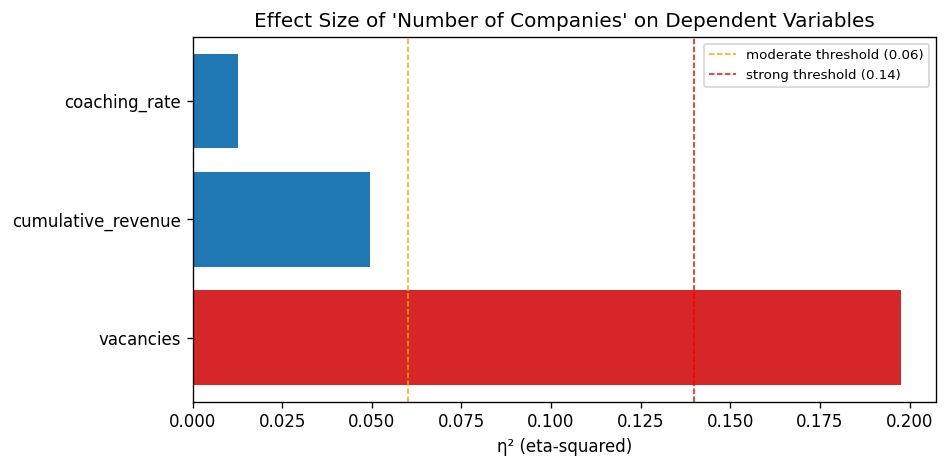

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = [
    "#d62728" if e == "strong" else "#ff7f0e" if e == "moderate" else "#1f77b4"
    for e in summary["effect"]
]
ax.barh(summary["dependent_variable"], summary["eta_squared"], color=colors)

ax.axvline(0.06, color="orange", linestyle="--", linewidth=0.9, label="moderate threshold (0.06)")
ax.axvline(0.14, color="red",    linestyle="--", linewidth=0.9, label="strong threshold (0.14)")

ax.set_xlabel("η² (eta-squared)")
ax.set_title(f"Effect Size of '{IV_LABEL}' on Dependent Variables")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8 · Box plots per dependent variable

C:\Users\svenj\AppData\Local\Temp\ipykernel_22852\3576954713.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(int(g)) for g in group_vals])
C:\Users\svenj\AppData\Local\Temp\ipykernel_22852\3576954713.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(int(g)) for g in group_vals])
C:\Users\svenj\AppData\Local\Temp\ipykernel_22852\3576954713.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(int(g)) for g in group_vals])


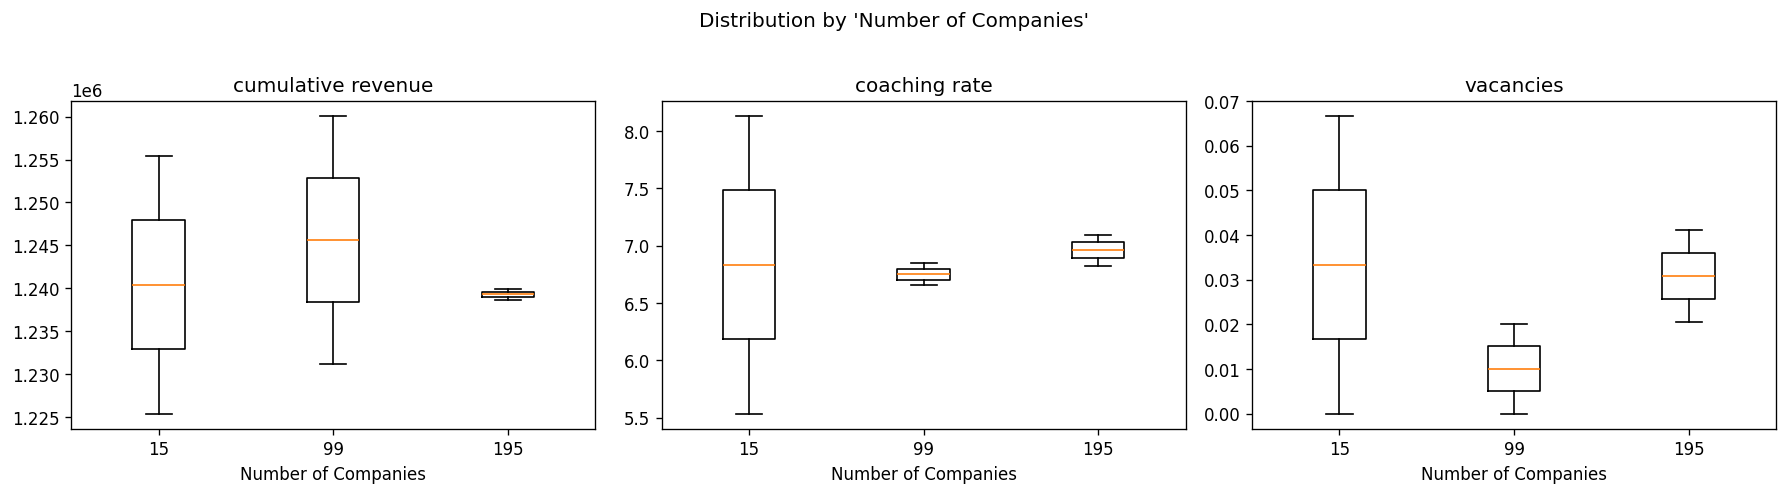

In [8]:
group_vals = sorted(df["num_companies"].unique())

fig, axes = plt.subplots(1, len(dv_names), figsize=(5 * len(dv_names), 4))
if len(dv_names) == 1:
    axes = [axes]

for ax, name in zip(axes, dv_names):
    data = [df.loc[df["num_companies"] == g, name].values for g in group_vals]
    ax.boxplot(data, labels=[str(int(g)) for g in group_vals])
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel(IV_LABEL)

plt.suptitle(f"Distribution by '{IV_LABEL}'", y=1.02)
plt.tight_layout()
plt.show()

## 9 · Export results

In [9]:
out_name = IV_LABEL.replace(" ", "_")
summary.to_csv(f"output/effect_sizes_{out_name}.csv", index=False)
print(f"Saved → output/effect_sizes_{out_name}.csv")

Saved → output/effect_sizes_Number_of_Companies.csv
